In [1]:
import cartopy.crs as crs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
from geobr import read_region
import geopandas as gpd
from shapely.geometry import box
import matplotlib.path as mpath
import numpy as np
from pyfonts import load_google_font

[shapereader](https://cartopy.readthedocs.io/stable/tutorials/using_the_shapereader.html)

In [2]:
# Load Natural Earth dataset 
countries = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_map_units"
)

In [3]:
# Filter for countries
countries_black = ["Haiti", "Dominican Rep.", "Bahamas", "Jamaica", "Cuba", "Puerto Rico"]
countries_brown = ["Venezuela","Guyana", "Suriname", "Trinidad and Tobago", "French Guiana"]

In [4]:
# Load Natural Earth states dataset
states = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_1_states_provinces"
)

In [5]:
# Filter for states
states_brown = ["Texas", "Oklahoma","Arkansas", "Louisiana", "Tennessee", "North Carolina", "Virginia"]
states_black = ["Mississippi", "Alabama", "Florida", "Georgia", "South Carolina"]

In [6]:
# Load Natural Earth lakes dataset
lakes = shpreader.natural_earth(
    resolution="110m",
    category="physical",
    name="lakes"
)

In [7]:
# Filter for lakes
great_lakes = [
    "Lake Superior",
    "Lake Michigan",
    "Lake Huron"    
]

In [8]:
# Load brazilian regions
br_region = read_region()
# Reproject to WGS84
br_region_4326 = br_region.to_crs("EPSG:4326")
# Filter for regions
brazil_black=br_region_4326[br_region_4326["name_region"].isin(["Nordeste", "Sudeste"])]
brazil_brown=br_region_4326[~br_region_4326["name_region"].isin(["Nordeste", "Sudeste"])]

In [9]:
# Colors
brown = "#74573b"
black = "#100e0c"
lake = "#dac2a8"
land = "#d4ab6c"

[set_extent](https://cartopy.readthedocs.io/stable/reference/generated/cartopy.mpl.geoaxes.GeoAxes.html#cartopy.mpl.geoaxes.GeoAxes.get_extent)

[data_crs](https://cartopy.readthedocs.io/stable/tutorials/understanding_transform.html)

[geo_axes](https://cartopy.readthedocs.io/stable/reference/generated/cartopy.mpl.geoaxes.GeoAxes.html#cartopy.mpl.geoaxes.GeoAxes)

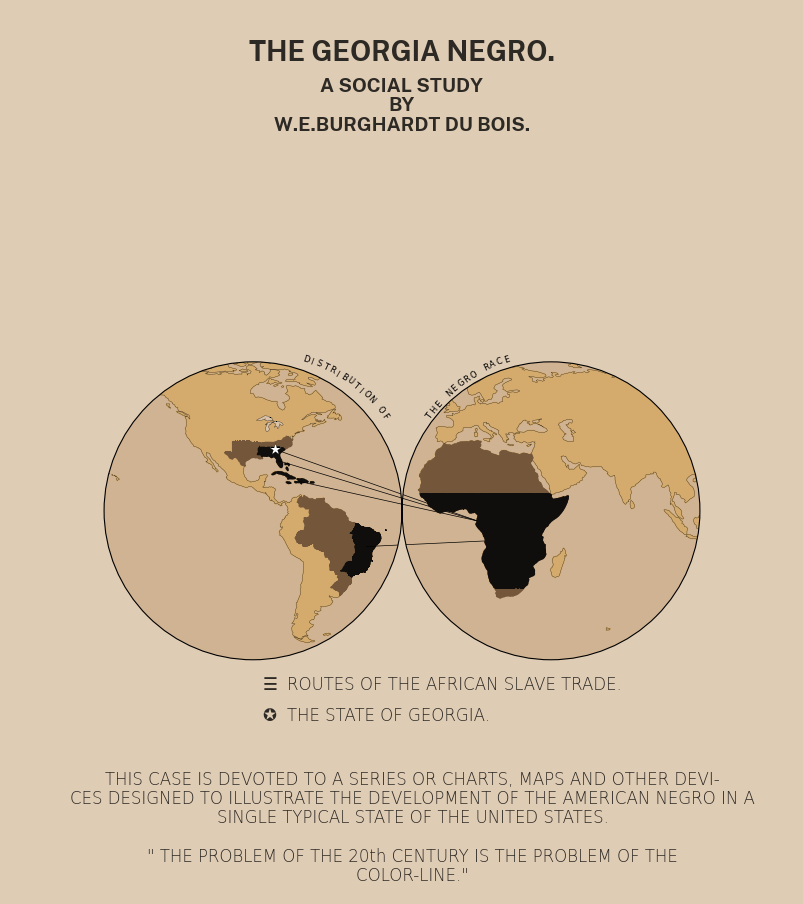

In [10]:
# Custom font
font = load_google_font("Public Sans", weight="bold")

# Create figure
fig = plt.figure(figsize=(8, 10))
# Create map axes with PlateCarree projection
ax_crs = crs.PlateCarree(central_longitude=-25.0)
# Create geo_axes (cartopy.mpl.geoaxes.GeoAxesSubplot) enabling later to clip perfect circles
ax = fig.add_subplot(projection=ax_crs)

# Make the map take up most of the fig area
ax.set_position([0.01, 0.01, 0.98, 0.98])

# Axes background color
ax.set_facecolor("#d6b999")

# Zoom map
ax.set_extent([180, -170, 90, -80], crs=crs.PlateCarree())

# Add land 
ax.add_feature(cfeature.LAND, color=land)

# Add coastline
ax.add_feature(cfeature.COASTLINE, lw=0.2)

# Add barzilian regions 
ax.add_geometries(
    brazil_brown.geometry,
    crs=crs.PlateCarree(),
    facecolor=brown,
    edgecolor=brown
)
ax.add_geometries(
    brazil_black.geometry,
    crs=crs.PlateCarree(),
    facecolor=black,
    edgecolor=black
)

# Add countries
reader = shpreader.Reader(countries)

for country in reader.records():
    name = country.attributes["NAME"]

    if name in countries_brown:
        color = brown
    elif name in countries_black:
        color = black    
    else:
        continue  

    ax.add_geometries(
        [country.geometry],
        crs=crs.PlateCarree(),
        facecolor=color,
        edgecolor=color
    )

# Add Africa
latitude_filter = box(-180, -30, 180, 13)
for country in reader.records():
    continent = country.attributes["CONTINENT"]
    name = country.attributes["ADMIN"]    

    if continent == "Africa" and name != "Madagascar":
    
        geom = country.geometry

        # Color entire Africa in brown
        ax.add_geometries(
            [geom],
            crs=crs.PlateCarree(),
            facecolor=brown,
            edgecolor=brown
        )

        # Compute intersection with latitude band
        intersection = geom.intersection(latitude_filter)

        # Color intersection area in black
        if not intersection.is_empty:
            ax.add_geometries(
                [intersection],
                crs=crs.PlateCarree(),
                facecolor=black,
                edgecolor=black,
                zorder=5  
            )

# Add US states
reader = shpreader.Reader(states)

for record in reader.records():
    if record.attributes["admin"] == "United States of America":
        state_name = record.attributes["name"]
        
        if state_name in states_brown:
            color = brown
        elif state_name in states_black:
            color = black
        else:
            continue   
        
        ax.add_geometries(
            [record.geometry],
            crs=crs.PlateCarree(),
            facecolor=color,
            edgecolor=color            
        )

# Add great lakes
reader = shpreader.Reader(lakes)

for record in reader.records():
    name = record.attributes["name"]

    if name in great_lakes:
        ax.add_geometries(
            [record.geometry],
            crs=crs.PlateCarree(),
            facecolor=lake,
            edgecolor="black",
            lw=0.2
        )

# Coords for the lines
lua_lon, lua_lat = 13.234444, -8.838333
bah_lon, bah_lat = -41.280857, -11.409874

lib_lon, lib_lat = 9.454400, 0.390100
hai_lon, hai_lat = -72.333336, 18.533333

lib_lon, lib_lat = 9.454400, 0.390100
flo_lon, flo_lat = -81.760254, 27.994402

lib_lon, lib_lat = 9.454400, 0.390100
geo_lon, geo_lat = -83.441162, 33.247875

# PLot the lines
data_crs = crs.PlateCarree()
ax.plot([lua_lon, bah_lon], [lua_lat, bah_lat], transform=data_crs,color="black", lw=0.5)
ax.plot([lib_lon, hai_lon], [lib_lat, hai_lat], transform=data_crs,color="black", lw=0.5)
ax.plot([lib_lon, flo_lon], [lib_lat, flo_lat], transform=data_crs,color="black", lw=0.5)
ax.plot([lib_lon, geo_lon], [lib_lat, geo_lat], transform=data_crs,color="black", lw=0.5)

# Mark Georgia
ax.scatter(geo_lon, geo_lat, s=75, facecolor="white", edgecolor="black", lw=0.2,  marker="*", transform=data_crs, zorder=2)

# Clip map to circles
x0, x1, y0, y1 = ax.get_extent()
r = x1*0.38
centrey = (y0+y1)/2
circle1 = mpath.Path.circle(center = (-r, centrey), radius=r)
circle2 = mpath.Path.circle(center = (r, centrey), radius=r)
circles = mpath.Path.make_compound_path(circle1, circle2)
ax.set_boundary(circles)  

# https://stackoverflow.com/a/44521963
# Function to plot arched text
def arched_text(ax, text, r, centerx, centery, theta_start, theta_end, offset=1.05, size=6):    
    rtxt = offset * r
    thetas = np.linspace(theta_start, theta_end, len(text))
    xs = rtxt * np.cos(thetas) + centerx
    ys = rtxt * np.sin(thetas) + centery

    for i, char in enumerate(text):
        rotation = 270 + np.degrees(thetas[i])
        ax.text(xs[i], ys[i], char, rotation=rotation, size=size)

# Add arched text
arched_text(ax, "DISTRIBUTION OF", r, -r, centrey, 0.4*np.pi, 0.2*np.pi)
arched_text(ax, "THE NEGRO RACE", r, r, centrey, 0.8*np.pi, 0.6*np.pi)

# Axes background color
ax.set_facecolor("#d0b393")

# Title and Subtitle
fig.text(0.5, 0.95, "\nTHE GEORGIA NEGRO.", font=font, alpha=0.8, size=20, ha="center")
fig.text(0.5, 0.88, "A SOCIAL STUDY\nBY\nW.E.BURGHARDT DU BOIS.", font=font, alpha=0.8, size=14, ha="center")

annotation1='''
    ☰ \n
    ✪ 
    '''

annotation2='''
    ROUTES OF THE AFRICAN SLAVE TRADE.\n
    THE STATE OF GEORGIA.
    '''

annotation3= '''
    THIS CASE IS DEVOTED TO A SERIES OR CHARTS, MAPS AND OTHER DEVI-\n
    CES DESIGNED TO ILLUSTRATE THE DEVELOPMENT OF THE AMERICAN NEGRO IN A\n
    SINGLE TYPICAL STATE OF THE UNITED STATES.\n
    \n
    " THE PROBLEM OF THE 20th CENTURY IS THE PROBLEM OF THE\n
    COLOR-LINE."
    '''

# Add annotations
fig.text(0.3, 0.35, annotation1, alpha=0.8, size="large", linespacing=0.8, va="top", ha="left")
fig.text(0.33, 0.35, annotation2, alpha=0.8, size="large", weight="light", linespacing=0.8, va="top", ha="left")
fig.text(0.5, 0.25, annotation3, alpha=0.8, size="large", weight="light", linespacing=0.4, va="top", ha="center")

# Fig backgroundcolor
fig.set_facecolor("#dfccb5")

plt.show()

# Saving the figure
#plt.savefig("plate01.jpg")

In [11]:
import numpy as np
import matplotlib.image as mpimg
from PIL import Image

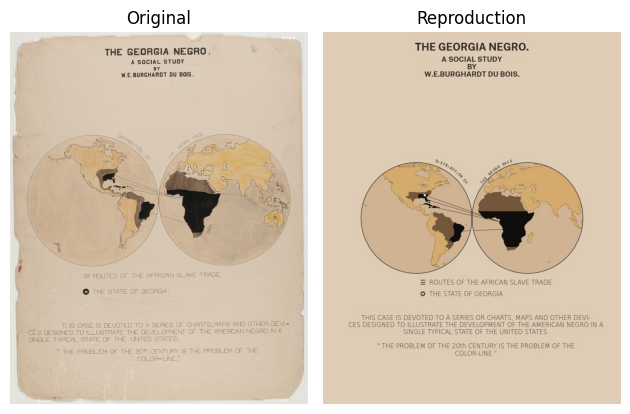

In [12]:
# Load images 
image1 = Image.open("original-plate-01.jpg")
image2 = Image.open("plate01.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate01sidebyside.png", dpi=300)